# CMP461 Pattern Recognition - Midterm Project
## Phase 1: Data Preprocessing & Visualization

**Author:** Efe Yaşar  
**Student ID:** 210408030 

--- 

### Objective / Amaç
This step involves loading the raw image dataset (cats, dogs, snakes), resizing them to 128x128, and normalizing them. We also visualize the dataset to verify correct labeling before splitting into Train/Val/Test.

In [16]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import random

IMG_SIZE = 128
DATASET_DIR = "DATASET"
CLASSES = ["cats", "dogs", "snakes"]
MAP = {0: "Cat", 1: "Dog", 2: "Snake"}
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

def load_data():
    X, y = [], []
    for index, category in enumerate(CLASSES):
        path = os.path.join(DATASET_DIR, category)
        if not os.path.exists(path): continue
        for img_name in tqdm(os.listdir(path), desc=f"Loading {category}"):
            try:
                img_path = os.path.join(path, img_name)
                img = cv2.imread(img_path)
                if img is None: continue
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                X.append(img)
                y.append(index)
            except Exception as e:
                continue
    return np.array(X), np.array(y)

print("🚀 Harvesting Data Samples...")
X, y = load_data()
print(f"✅ Total Images Loaded: {len(X)}")

🚀 Harvesting Data Samples...


Loading snakes: 100%|██████████| 1000/1000 [00:00<00:00, 1708.74it/s]


✅ Total Images Loaded: 3000


### Visual Verification / Görsel Doğrulama
Let's see some random samples from our dataset.

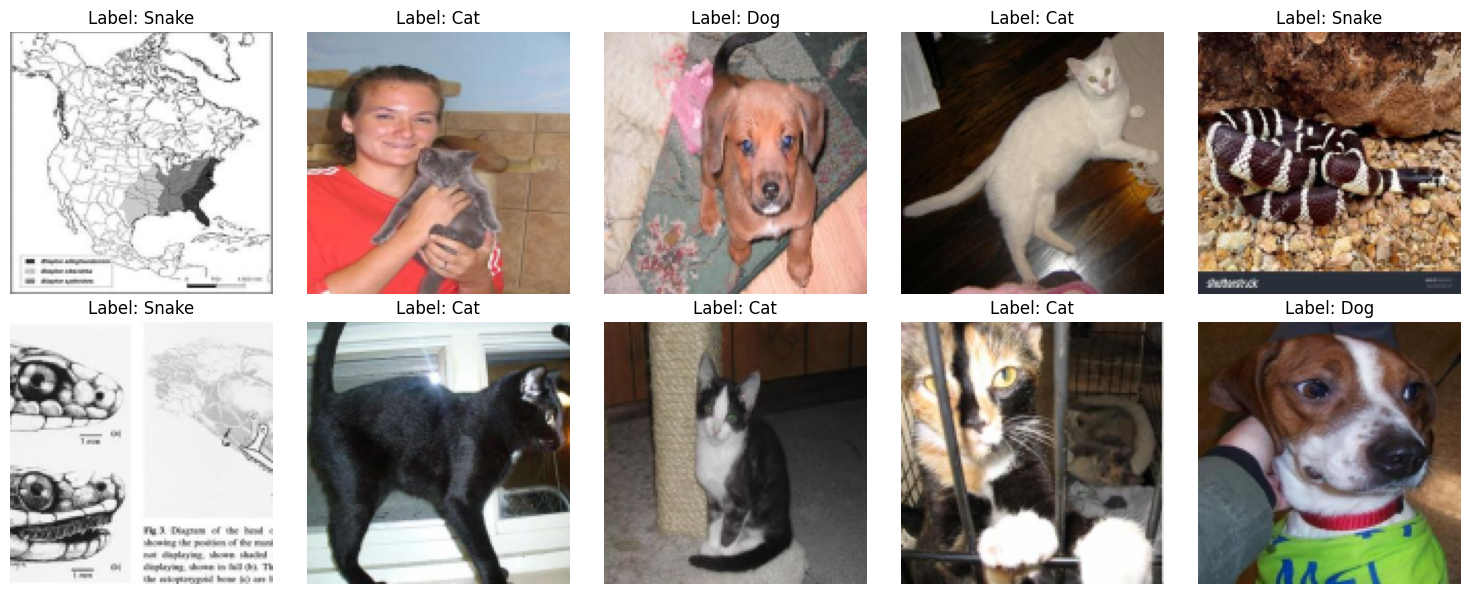

In [17]:
plt.figure(figsize=(15, 6))
for i in range(10):
    idx = random.randint(0, len(X)-1)
    plt.subplot(2, 5, i+1)
    plt.imshow(X[idx])
    plt.title(f"Label: {MAP[y[idx]]}")
    plt.axis("off")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/data_prep_verification.png")
plt.show()

### Train/Val/Test Splitting & Normalization
We use a **70/15/15** split ratio.

In [18]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

X_train, X_val, X_test = X_train/255.0, X_val/255.0, X_test/255.0

np.savez("preprocessed_data.npz", X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val, X_test=X_test, y_test=y_test)
print(f"📦 Data Partitioned: {len(X_train)} Train, {len(X_val)} Val, {len(X_test)} Test")
print("✅ Serialization to preprocessed_data.npz successful.")

📦 Data Partitioned: 2100 Train, 450 Val, 450 Test
✅ Serialization to preprocessed_data.npz successful.
